# OhioT1DM – Exploratory Data Analysis
**Purpose:** Understand the dataset structure, glucose dynamics, missing data patterns,
physiological feature distributions, stationarity, and feature-target correlations
before any modelling is performed.

> This notebook is **EDA only**. All modelling lives in `main.py` and `src/models/`.

In [3]:
import os
import sys
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

def find_project_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "configs" / "config.yaml").exists() and (path / "src").exists():
            return path
    raise FileNotFoundError("Could not find project root containing configs/config.yaml and src/")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from src.utils.config_loader import load_config
from src.utils.seed import set_global_seed
from src.data.parser import OhioT1DMParser
from src.data.loader import find_xml_files, build_all_masters

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 100

cfg = load_config(PROJECT_ROOT / "configs" / "config.yaml")
set_global_seed(cfg["seed"])

DATA_DIR   = PROJECT_ROOT / cfg["paths"]["data_dir"]
PLOTS_DIR  = PROJECT_ROOT / cfg["paths"]["plots_dir"]
os.makedirs(PLOTS_DIR, exist_ok=True)

print("Config loaded. Data dir:", DATA_DIR)

Config loaded. Data dir: C:\Users\Admin\Desktop\blood-glucose-prediction\src\data\OhioT1DM


## 1. File Discovery

In [4]:
ds_cfg = cfg["dataset"]
train_files, test_files = find_xml_files(
    DATA_DIR,
    ds_cfg["cohorts"],
    ds_cfg.get("train_suffix", "-ws-training.xml"),
    ds_cfg.get("test_suffix",  "-ws-testing.xml"),
)

print(f"Train files: {len(train_files)}")
print(f"Test  files: {len(test_files)}")
for k in sorted(train_files):
    print(f"  {k}: {train_files[k]}")

Train files: 12
Test  files: 12
  540_2020: C:\Users\Admin\Desktop\blood-glucose-prediction\src\data\OhioT1DM\2020\train\540-ws-training.xml
  544_2020: C:\Users\Admin\Desktop\blood-glucose-prediction\src\data\OhioT1DM\2020\train\544-ws-training.xml
  552_2020: C:\Users\Admin\Desktop\blood-glucose-prediction\src\data\OhioT1DM\2020\train\552-ws-training.xml
  559_2018: C:\Users\Admin\Desktop\blood-glucose-prediction\src\data\OhioT1DM\2018\train\559-ws-training.xml
  563_2018: C:\Users\Admin\Desktop\blood-glucose-prediction\src\data\OhioT1DM\2018\train\563-ws-training.xml
  567_2020: C:\Users\Admin\Desktop\blood-glucose-prediction\src\data\OhioT1DM\2020\train\567-ws-training.xml
  570_2018: C:\Users\Admin\Desktop\blood-glucose-prediction\src\data\OhioT1DM\2018\train\570-ws-training.xml
  575_2018: C:\Users\Admin\Desktop\blood-glucose-prediction\src\data\OhioT1DM\2018\train\575-ws-training.xml
  584_2020: C:\Users\Admin\Desktop\blood-glucose-prediction\src\data\OhioT1DM\2020\train\584-ws-

## 2. Missing Data Analysis

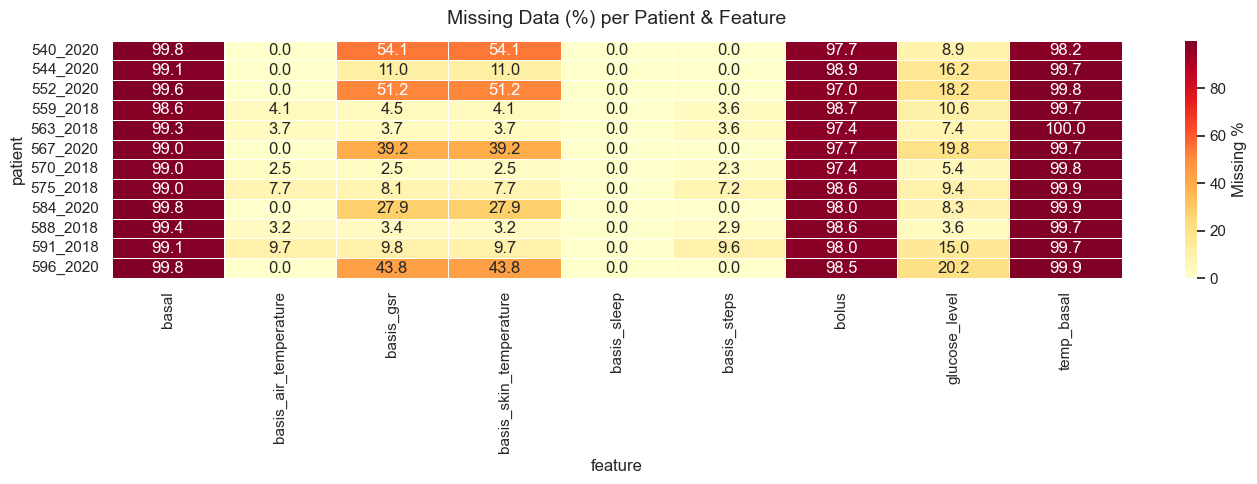


Glucose-level missing data:


,patient,actual,expected,missing,missing_pct
0,559_2018,10796,12081,1285,10.64
9,563_2018,12124,13098,974,7.44
18,570_2018,10982,11611,629,5.42
27,575_2018,11866,13104,1238,9.45
36,588_2018,12640,13106,466,3.56
45,591_2018,10847,12755,1908,14.96
54,540_2020,11947,13109,1163,8.87
63,544_2020,10623,12672,2049,16.17
72,552_2020,9080,11097,2017,18.18
81,567_2020,10858,13536,2678,19.78


In [5]:
FEATURES = ds_cfg["features"]
missing_records = []

for key, path in train_files.items():
    for feat in FEATURES:
        parser = OhioT1DMParser(path, feat)
        info   = parser.missing_stats()
        missing_records.append(dict(patient=key, feature=feat, **info))

missing_df = pd.DataFrame(missing_records)
pivot = missing_df.pivot(index="patient", columns="feature", values="missing_pct")

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Missing %"})
ax.set_title("Missing Data (%) per Patient & Feature", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_missing_heatmap.png"), bbox_inches="tight")
plt.show()

# Glucose missing summary
print("\nGlucose-level missing data:")
display(
    missing_df[missing_df.feature == "glucose_level"][
        ["patient", "actual", "expected", "missing", "missing_pct"]
    ]
)

In [6]:

print(FEATURES)

['glucose_level', 'bolus', 'basal', 'temp_basal', 'basis_gsr', 'basis_skin_temperature', 'basis_air_temperature', 'basis_steps', 'basis_sleep']


## 3. Raw Glucose Visualisation

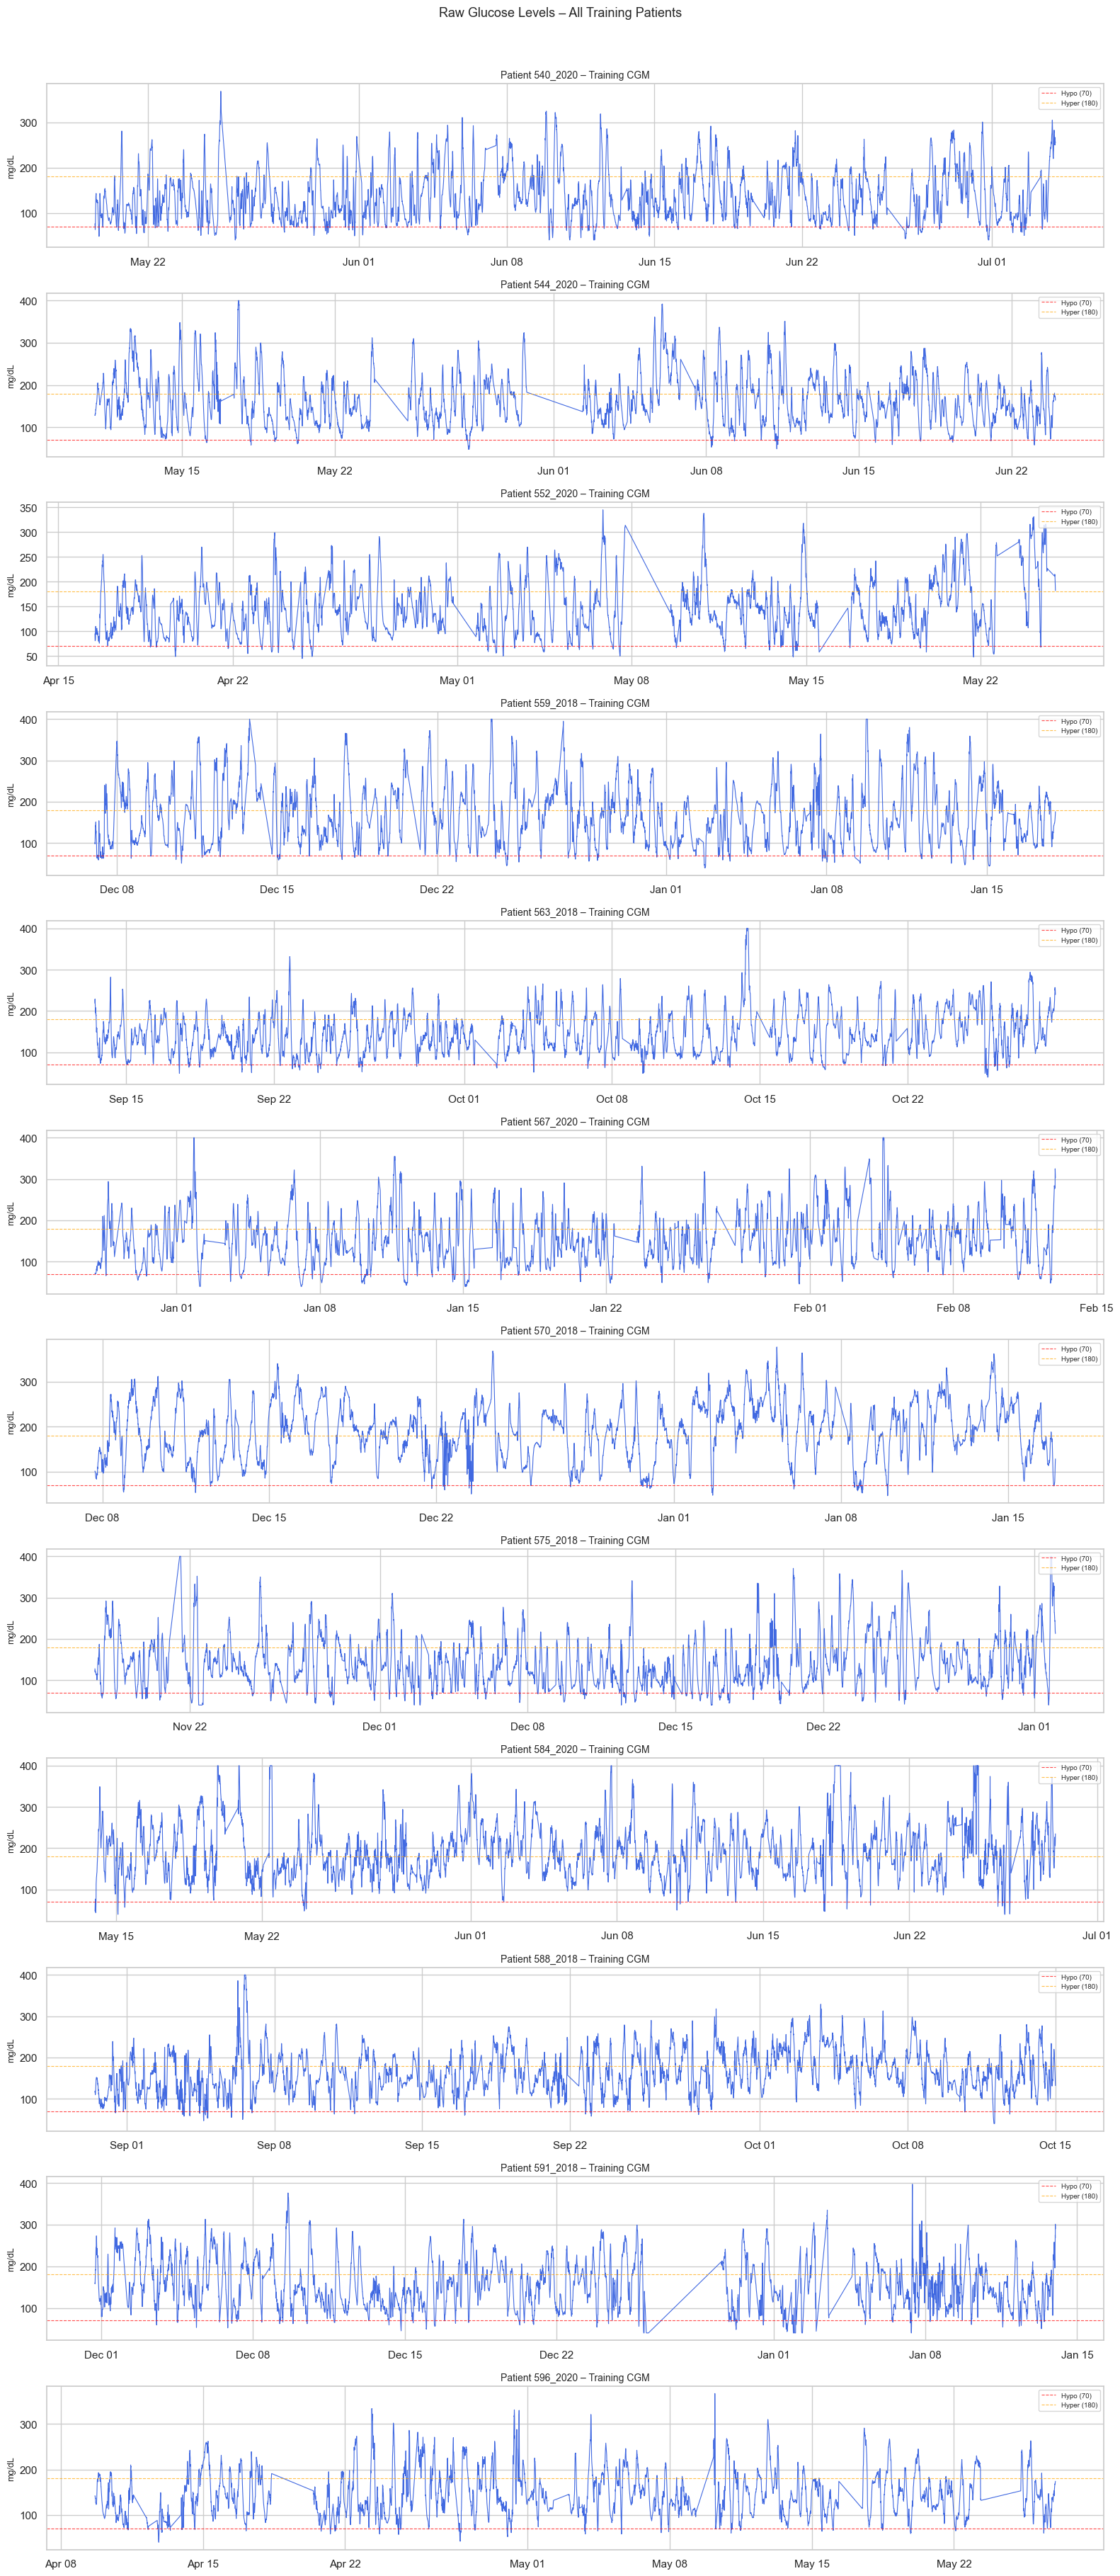

In [ ]:
n = len(train_files)
fig, axes = plt.subplots(n, 1, figsize=(16, 3 * n), sharex=False)
if n == 1:
    axes = [axes]

for ax, (key, path) in zip(axes, sorted(train_files.items())):
    df = OhioT1DMParser(path, "glucose_level").make_dataframe()
    ax.plot(df.index, df["value"], lw=0.8, color="royalblue")
    ax.axhline(70,  ls="--", color="red",    lw=0.8, alpha=0.7, label="Hypo (70)")
    ax.axhline(180, ls="--", color="orange", lw=0.8, alpha=0.7, label="Hyper (180)")
    ax.set_ylabel("mg/dL", fontsize=9)
    ax.set_title(f"Patient {key} – Training CGM", fontsize=10)
    ax.legend(fontsize=7, loc="upper right")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.suptitle("Raw Glucose Levels – All Training Patients", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_raw_glucose.png"), bbox_inches="tight")
plt.show()

## 4. Glucose Distribution per Patient

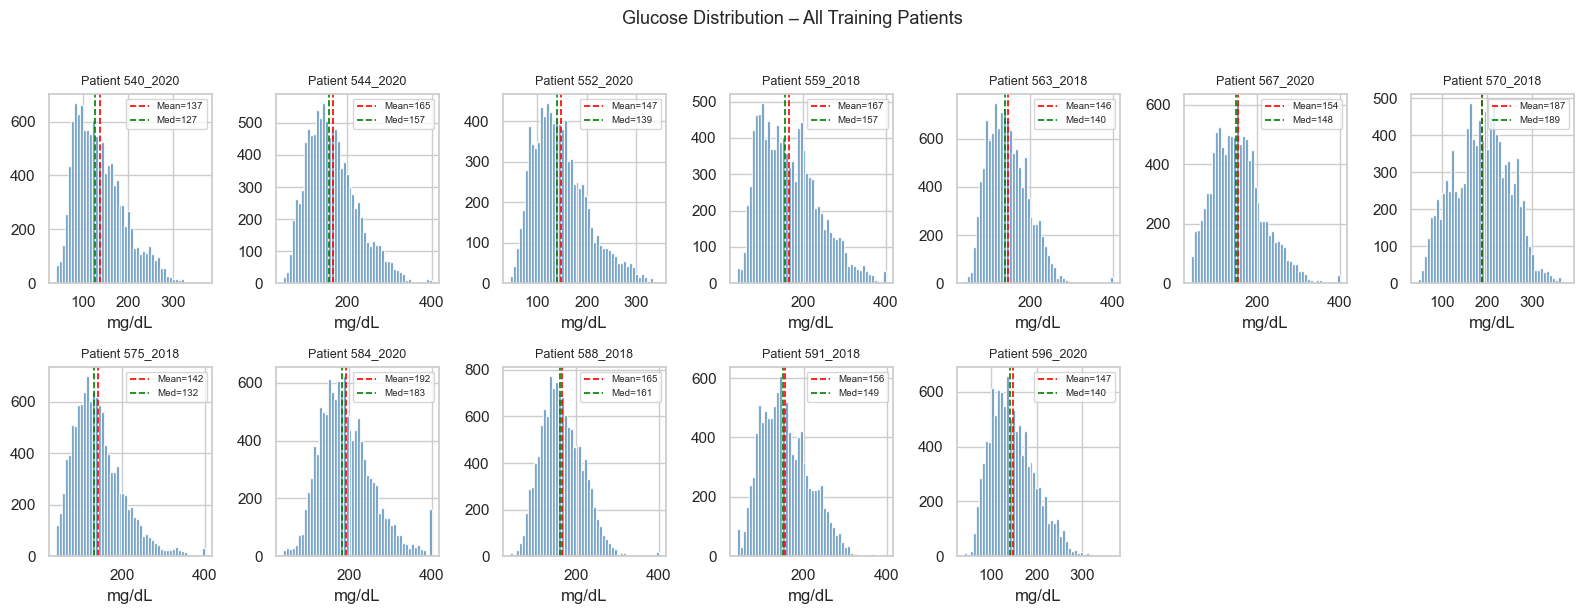

In [ ]:
fig, axes = plt.subplots(2, n // 2 + 1, figsize=(16, 6))
axes = axes.flatten()

for i, (key, path) in enumerate(sorted(train_files.items())):
    df = OhioT1DMParser(path, "glucose_level").make_dataframe()
    gl = df["value"].dropna()
    axes[i].hist(gl, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].axvline(gl.mean(), color="red",    ls="--", lw=1.2, label=f"Mean={gl.mean():.0f}")
    axes[i].axvline(gl.median(), color="green", ls="--", lw=1.2, label=f"Med={gl.median():.0f}")
    axes[i].set_title(f"Patient {key}", fontsize=9)
    axes[i].set_xlabel("mg/dL")
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Glucose Distribution – All Training Patients", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_glucose_distributions.png"), bbox_inches="tight")
plt.show()

## 5. Time-in-Range (TIR) Analysis

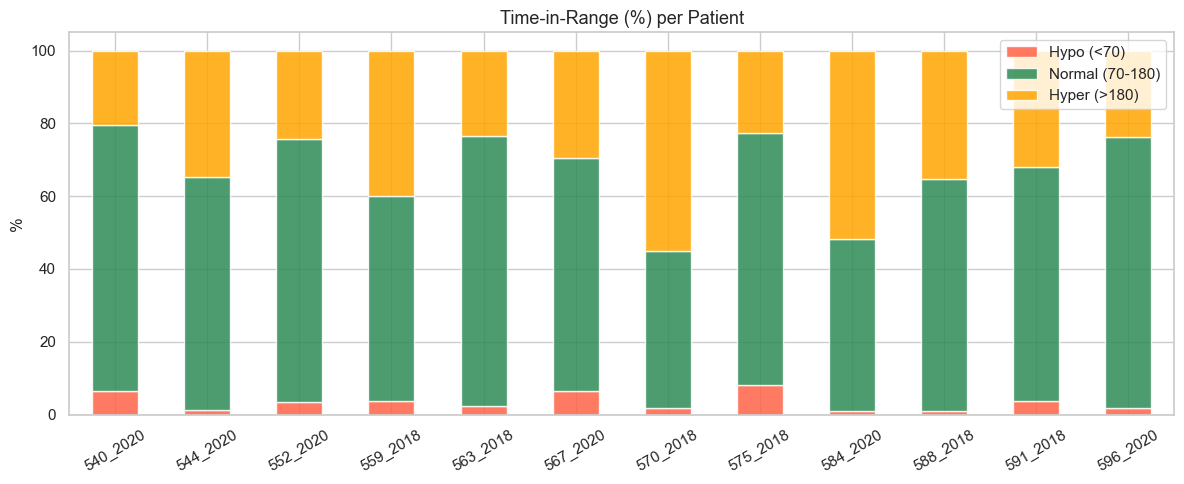

 patient  hypo_pct  normal_pct  hyper_pct
540_2020  6.353059   73.181552  20.465389
544_2020  1.374376   63.776711  34.848913
552_2020  3.425110   72.312775  24.262115
559_2018  3.788440   56.233790  39.977770
563_2018  2.301221   74.158694  23.540086
567_2020  6.400810   64.044944  29.554246
570_2018  1.784739   43.152431  55.062830
575_2018  8.132479   69.197708  22.669813
584_2020  0.880658   47.432099  51.687243
588_2018  0.949367   63.655063  35.395570
591_2018  3.696875   64.202084  32.101042
596_2020  1.893905   74.220833  23.885262


In [ ]:
tir_records = []
for key, path in sorted(train_files.items()):
    df = OhioT1DMParser(path, "glucose_level").make_dataframe()
    gl = df["value"].dropna()
    total = len(gl)
    tir_records.append(dict(
        patient=key,
        hypo_pct   = (gl < 70).sum()   / total * 100,
        normal_pct = ((gl >= 70) & (gl <= 180)).sum() / total * 100,
        hyper_pct  = (gl > 180).sum()  / total * 100,
    ))

tir_df = pd.DataFrame(tir_records)
ax = tir_df.set_index("patient").plot(
    kind="bar", stacked=True, figsize=(12, 5),
    color=["tomato", "seagreen", "orange"], alpha=0.85,
)
ax.set_title("Time-in-Range (%) per Patient", fontsize=13)
ax.set_ylabel("%")
ax.set_xlabel("")
ax.legend(["Hypo (<70)", "Normal (70-180)", "Hyper (>180)"], loc="upper right")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_time_in_range.png"), bbox_inches="tight")
plt.show()
print(tir_df.to_string(index=False))

## 6. Stationarity Check (ADF Test)

In [ ]:
adf_records = []
for key, path in sorted(train_files.items()):
    parser = OhioT1DMParser(path, "glucose_level")
    df     = parser.make_dataframe().resample("5min").mean().interpolate()
    series = df["value"].dropna()
    if len(series) < 20:
        continue
    result = adfuller(series, autolag="AIC")
    adf_records.append(dict(
        patient   = key,
        adf_stat  = round(result[0], 4),
        p_value   = round(result[1], 4),
        stationary= "Yes" if result[1] < 0.05 else "No",
    ))

adf_df = pd.DataFrame(adf_records)
print("Augmented Dickey-Fuller Stationarity Test – Glucose Level")
display(adf_df)

Augmented Dickey-Fuller Stationarity Test – Glucose Level


,patient,adf_stat,p_value,stationary
0,540_2020,-13.6461,0.0,Yes
1,544_2020,-11.9827,0.0,Yes
2,552_2020,-10.1996,0.0,Yes
3,559_2018,-12.5473,0.0,Yes
4,563_2018,-13.9806,0.0,Yes
5,567_2020,-14.7196,0.0,Yes
6,570_2018,-9.5056,0.0,Yes
7,575_2018,-13.0720,0.0,Yes
8,584_2020,-11.2371,0.0,Yes
9,588_2018,-11.8898,0.0,Yes


## 7. ACF & PACF for a Representative Patient

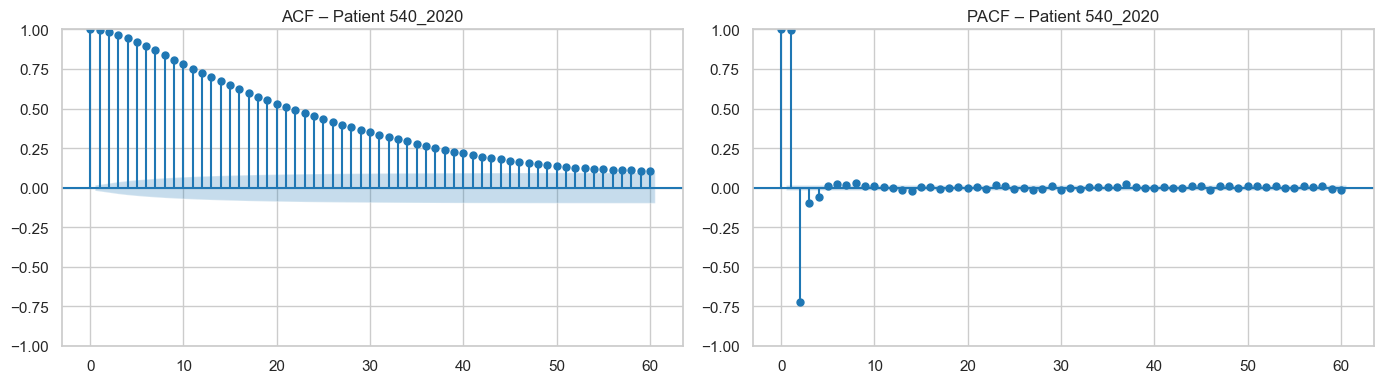

In [ ]:
sample_key  = sorted(train_files.keys())[0]
sample_path = train_files[sample_key]
gl_series   = (
    OhioT1DMParser(sample_path, "glucose_level")
    .make_dataframe()
    .resample("5min").mean()
    .interpolate()["value"]
    .dropna()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(gl_series,  lags=60, ax=axes[0], title=f"ACF – Patient {sample_key}")
plot_pacf(gl_series, lags=60, ax=axes[1], title=f"PACF – Patient {sample_key}")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_acf_pacf.png"), bbox_inches="tight")
plt.show()

## 8. Feature Engineering & Correlation Analysis

In [ ]:
train_masters = build_all_masters(train_files, cfg)
all_train     = pd.concat(list(train_masters.values()), ignore_index=True)

feature_cols = ["total_insulin", "insulin_count", "insulin_3h_std", "daily_exercise"]

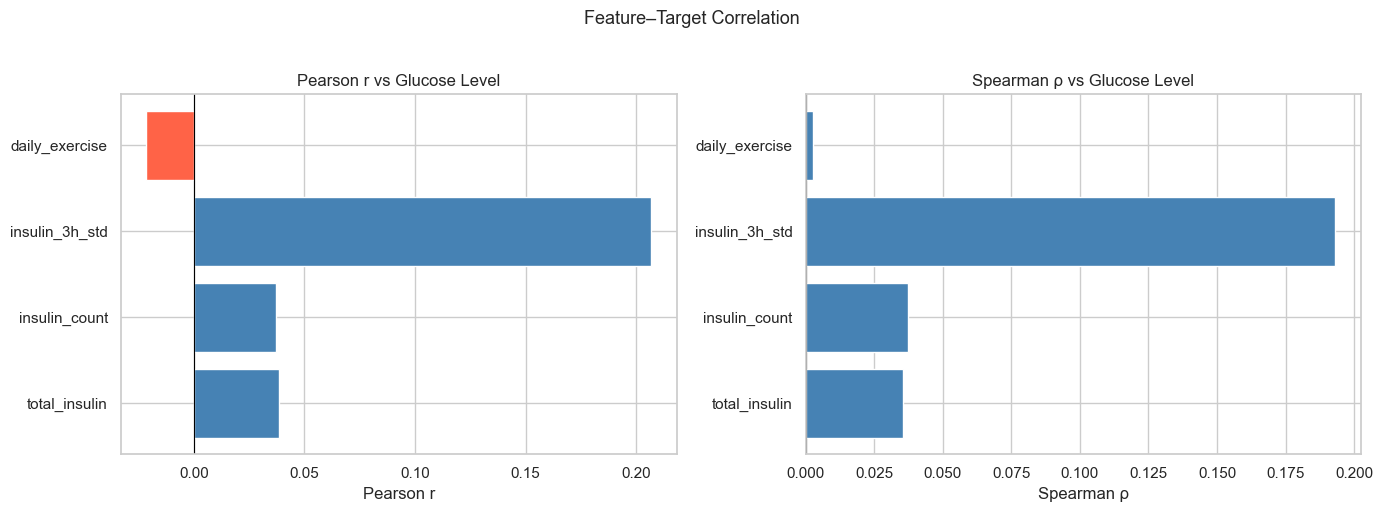


Pearson:


,r,p-value
total_insulin,0.0383,0.0
insulin_count,0.0370,0.0
insulin_3h_std,0.2069,0.0
daily_exercise,-0.0215,0.0



Spearman:


,r,p-value
total_insulin,0.0355,0.0000
insulin_count,0.0374,0.0000
insulin_3h_std,0.1929,0.0000
daily_exercise,0.0028,0.2807


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pearson_r, spearman_r = {}, {}

for col in feature_cols:
    r, p = stats.pearsonr(all_train[col].fillna(0), all_train["glucose_level"])
    pearson_r[col]  = (round(r, 4), round(p, 4))
    r2, p2 = stats.spearmanr(all_train[col].fillna(0), all_train["glucose_level"])
    spearman_r[col] = (round(r2, 4), round(p2, 4))

pearson_df  = pd.DataFrame(pearson_r,  index=["r", "p-value"]).T
spearman_df = pd.DataFrame(spearman_r, index=["r", "p-value"]).T

for ax, corr_df, title, xlabel in [
    (axes[0], pearson_df,  "Pearson r vs Glucose Level",  "Pearson r"),
    (axes[1], spearman_df, "Spearman ρ vs Glucose Level", "Spearman ρ"),
]:
    colors = ["steelblue" if v >= 0 else "tomato" for v in corr_df["r"]]
    ax.barh(corr_df.index, corr_df["r"], color=colors)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel)

plt.suptitle("Feature–Target Correlation", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_correlation.png"), bbox_inches="tight")
plt.show()

print("\nPearson:"); display(pearson_df)
print("\nSpearman:"); display(spearman_df)

## 9. Engineered Feature Distributions

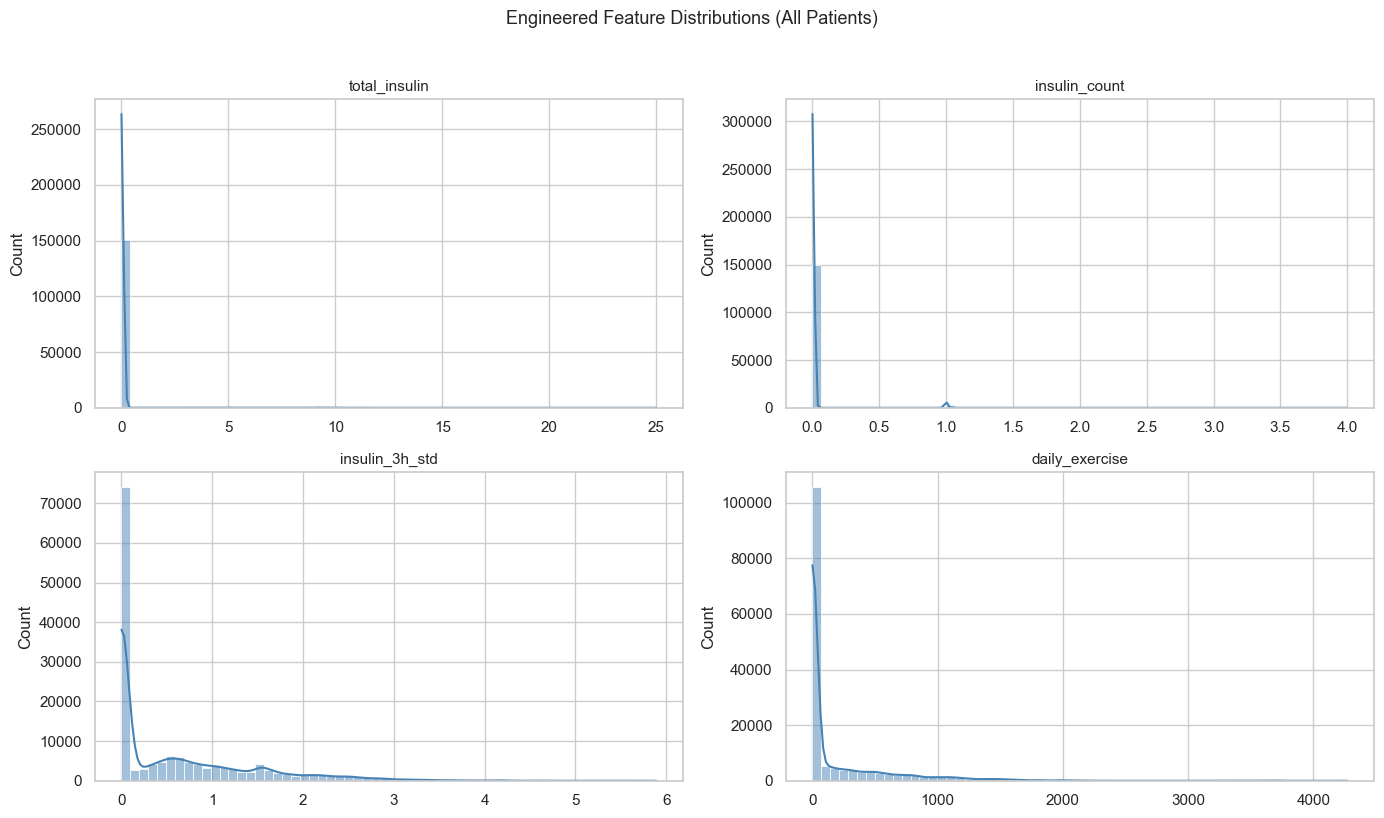

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), feature_cols):
    data = all_train[col].dropna()
    sns.histplot(data, bins=60, ax=ax, color="steelblue", kde=True)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")
plt.suptitle("Engineered Feature Distributions (All Patients)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_feature_distributions.png"), bbox_inches="tight")
plt.show()

## 10. Insulin vs Glucose Relationship

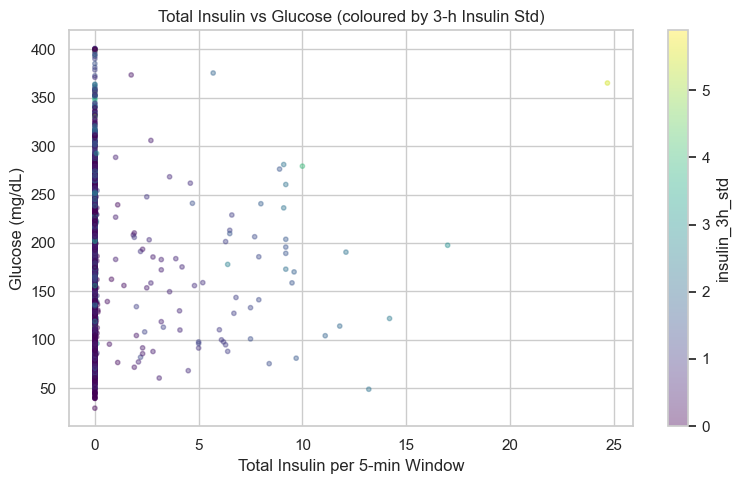

In [ ]:
sample = all_train.sample(min(5000, len(all_train)), random_state=42)
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(sample["total_insulin"], sample["glucose_level"],
                c=sample["insulin_3h_std"], cmap="viridis", alpha=0.4, s=10)
plt.colorbar(sc, ax=ax, label="insulin_3h_std")
ax.set_xlabel("Total Insulin per 5-min Window")
ax.set_ylabel("Glucose (mg/dL)")
ax.set_title("Total Insulin vs Glucose (coloured by 3-h Insulin Std)")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_insulin_glucose_scatter.png"), bbox_inches="tight")
plt.show()

## 11. Summary Statistics

In [ ]:
summary = all_train.describe().T
display(summary)
summary.to_csv(os.path.join(cfg["paths"]["results_dir"], "eda_summary_stats.csv"))
print("EDA complete. Plots saved to:", PLOTS_DIR)

,count,mean,std,min,25%,50%,75%,max
glucose_level,153046.0,159.190177,59.615297,13.582751,113.928322,151.954545,195.207459,424.000000
total_insulin,153046.0,0.116710,1.028810,0.000000,0.000000,0.000000,0.000000,25.000000
insulin_count,153046.0,0.019589,0.141245,0.000000,0.000000,0.000000,0.000000,4.000000
insulin_3h_std,153046.0,0.612123,0.825711,0.000000,0.000000,0.183333,1.005638,5.890452
daily_exercise,153046.0,194.696320,410.787453,0.000000,0.000000,0.000000,200.000000,4271.000000


EDA complete. Plots saved to: C:\Users\Admin\Desktop\blood-glucose-prediction\output\plots
